In [2]:
#Notebook Imports
import sys; sys.path.insert(0, "..")
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import torch
import src.analysis as an
import src.kz_ml as kzml

Using `scripts.kz2d.generate_data.py` we've generated a lot of data, and using BU's super-computing cluster I have trained a neural network to predict the final field values of the 2D $\phi^4$ model.

If you would like to use this notebook, we provide the training weights. You will need to run `kz2d.generate_data.py` yourself. You are also welcome of course to change the model we used to train, and see if you can do better!

The model we use is a U-net model. These are very popular for analyzing image data, or spatially correlated data. Unets are useful because they allow the model to learn about features on different length scales. 

![U-Net](../figures/2d/unet_diagram.png)


Roughly, a UNET works by running a filter over the image. This filter has trainable parameters in it, and can be thought of as a "feature selector". For instance, this filter might distinguish only edges in an image, or it might blur the image to only look at the "broad strokes". The output of this filter is a number, which assigned to each pixel. Then we downsample the image, which means we reduce its size by using `MaxPool`. Then we run another filter over it, which produces more numbers, which we downsample again and so on. Afterwards, we upsample using skip connections. 


Let's look at the model used in training. We can call it from `src.kz_ml` as `UNet()`. 

In [4]:
N = 256                                     # lattice size of the v2 data

model  = kzml.UNet()
block_names = ["down1", "down2", "down3", "bottom", "up3", "up2", "up1", "out"]

# record each block's output shape with forward hooks
shapes = {}
for name in block_names:
    getattr(model, name).register_forward_hook(
        lambda mod, inp, out, name=name: shapes.__setitem__(name, tuple(out.shape[1:])))

with torch.no_grad():
    y = model(torch.zeros(1, 1, N, N))      # one dummy input field

print(f"{'block':<8} {'output (channels, H, W)':<26} {'params':>10}")
print("-" * 46)
for name in block_names:
    n_par = sum(p.numel() for p in getattr(model, name).parameters())
    note  = "   <- + skip from " + {"up3": "down3", "up2": "down2", "up1": "down1"}[name] \
            if name in ("up3", "up2", "up1") else ""
    print(f"{name:<8} {str(shapes[name]):<26} {n_par:>10,}{note}")
print("-" * 46)
print(f"{'total':<35} {sum(p.numel() for p in model.parameters()):>10,}")
print(f"\ninput (1, {N}, {N})  ->  output {tuple(y.shape[1:])}: one logit per site (>0 = predict +)")

block    output (channels, H, W)        params
----------------------------------------------
down1    (16, 256, 256)                  2,480
down2    (32, 128, 128)                 13,888
down3    (64, 64, 64)                   55,424
bottom   (128, 32, 32)                 221,440
up3      (64, 64, 64)                  147,584   <- + skip from down3
up2      (32, 128, 128)                 36,928   <- + skip from down2
up1      (16, 256, 256)                  9,248   <- + skip from down1
out      (1, 256, 256)                      17
----------------------------------------------
total                                  487,009

input (1, 256, 256)  ->  output (1, 256, 256): one logit per site (>0 = predict +)


We can see from the printout above that the model downsamples the image until it is $32 \times 32$, after which it upsamples back to being $256\times 256$

This model was trained using a single snapshot of the field configuration at specific times $t'=t/\hat t$. This means unlike in the one dimensional case we are foregoing any momentum information.

# Training Results

Let's se ehow well these mdoels trained.

best epoch (of 0-29) by validation accuracy
  tau     0   0.5     1   1.5     2     3     4     5     6     7     8     9
    8    22    27    19    26    27    26    27    29    27    29    25    28
   16    12    23    27    29    22    27    28    27    26    20    24    27
   32    24    25    26    23    24    26    29    25    29    29    20    26
   64    29    21    28    27    29    29    29    27    26    24    29    29
  128    23    23    29    25    29    22    24    28    29    26    29    28
  256    26    29    27    29    29    29    26    24    29    29    29    20


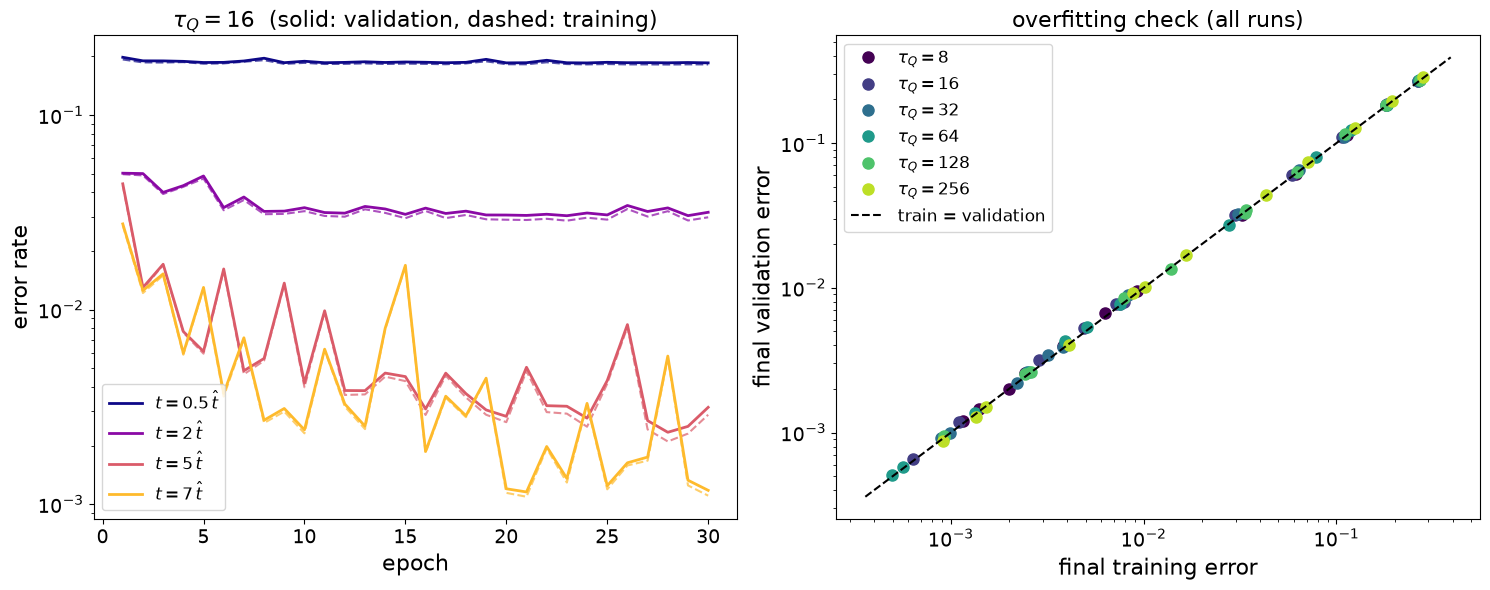

In [9]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
T_LIST   = [0, 0.5, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9]
TAU_LC   = 16                       # tau shown in the learning-curve panel
T_LC     = [1/2,2,5,7]             # times shown in the learning-curve panel
TARGET   = "y_end"
FONTSIZE = 16

# ---- table: best epoch per (tau, t) ----
print("best epoch (of 0-29) by validation accuracy")
print(f"{'tau':>5} " + " ".join(f"{t:>5g}" for t in T_LIST))
for tau in TAUS:
    res = {r["t_used"]: r for r in an.load_results(tau, target=TARGET)}
    row = [int(np.argmax(np.array(res[t]["history"])[:, 3])) if t in res else -1 for t in T_LIST]
    print(f"{tau:>5} " + " ".join(f"{b:>5d}" for b in row))

# ---- figure ----
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# left: learning curves for one tau
res = {r["t_used"]: r for r in an.load_results(TAU_LC, target=TARGET)}
colors = plt.cm.plasma(np.linspace(0, 0.85, len(T_LC)))
for t, c in zip(T_LC, colors):
    h  = np.array(res[t]["history"])            # columns: train_loss, val_loss, train_acc, val_acc
    ep = np.arange(1, len(h) + 1)
    ax[0].semilogy(ep, 1 - h[:, 3], "-",  color=c, lw=2, label=rf"$t = {t:g}\,\hat t$")
    ax[0].semilogy(ep, 1 - h[:, 2], "--", color=c, lw=1.5, alpha=0.7)
ax[0].set_xlabel("epoch", fontsize=FONTSIZE)
ax[0].set_ylabel("error rate", fontsize=FONTSIZE)
ax[0].set_title(rf"$\tau_Q = {TAU_LC}$  (solid: validation, dashed: training)", fontsize=FONTSIZE)
ax[0].legend(fontsize=FONTSIZE - 4)

# right: final train vs validation error, every run
colors = plt.cm.viridis(np.linspace(0, 0.9, len(TAUS)))
for tau, c in zip(TAUS, colors):
    tr, va = [], []
    for r in an.load_results(tau, target=TARGET):
        h = np.array(r["history"])
        tr.append(1 - h[-1, 2]); va.append(1 - h[-1, 3])
    ax[1].loglog(tr, va, "o", color=c, ms=8, label=rf"$\tau_Q = {tau}$")
lims = [min(ax[1].get_xlim()[0], ax[1].get_ylim()[0]), max(ax[1].get_xlim()[1], ax[1].get_ylim()[1])]
ax[1].plot(lims, lims, "k--", lw=1.5, label="train = validation")
ax[1].set_xlabel("final training error", fontsize=FONTSIZE)
ax[1].set_ylabel("final validation error", fontsize=FONTSIZE)
ax[1].set_title("overfitting check (all runs)", fontsize=FONTSIZE)
ax[1].legend(fontsize=FONTSIZE - 4)

for a in ax:
    a.tick_params(labelsize=FONTSIZE - 2)
plt.tight_layout()
plt.savefig("../figures/2d/training_statistics.png", dpi=150)
plt.show()

The plots above give us an idea of how the training worked. On the left, we see validation and training error. These always closely follow one another, with validation error always being larger than the training error. This is a sign that we are not overfitting, as when the model does worse/better on training data, it also does equally worse/better on the validation set. This is shown in the right plot, where the collapse of the training errors and validation errors onto a single linear curve shows we are not overfitting.

We can see on the left, that for early times, the model quickly learns and does not do much better as we run it longer. On the other hand, for larger times it looks like the model may still have been learning by the time the 30 training epochs were running. It may be interesting to train deeper or with a better scheduler, but for now, we simply acknowledge this and say that our UNET errors are conservative upper bounds in these regimes. 



This leads us to an interesting question. If the model quickly learns in the early time regimes, (eg. $t=0.5\hat t$)  what exactly is it learning? Did we need to use machine learning to reach this result? And if the network needs much data and time to learn the later times, why?


One might naively think these curves should be the opposite. After all, at later times, the field is already quite close to the final configuration, what more does it need to learn? 

# Gaussian Blurring compared to UNET

With a single snapshot of the field values, we lose any information about the momentum of the field. There are other schemes that can try and predict the final error, one way is through gaussian blurring.


We consider convolving the field with a guassian kernel:
$$u(r,t)= (G_\sigma * \phi)(r)$$

with 
$$G_\sigma(r)=(2\pi\sigma^2)^{-1} e^{-|r|^2/2\sigma^2}$$

Given that the field is periodic, we can go to fourier space to find:

$$u(k)=\phi(k)e^{-k^2\sigma^2/2}$$

In other words, a choice of $\sigma$ (which defines our gaussian kernel) supresses higher momentum modes. The logic is simple, the physics should primarily be determined by the low wavelength modes with a cutoff set by $k_c\sim 1/\xi_{KZ}$.

By using a guassian kernel, we can simply scan over $\sigma$ values and select the one that optimizes the error of the configuration. 


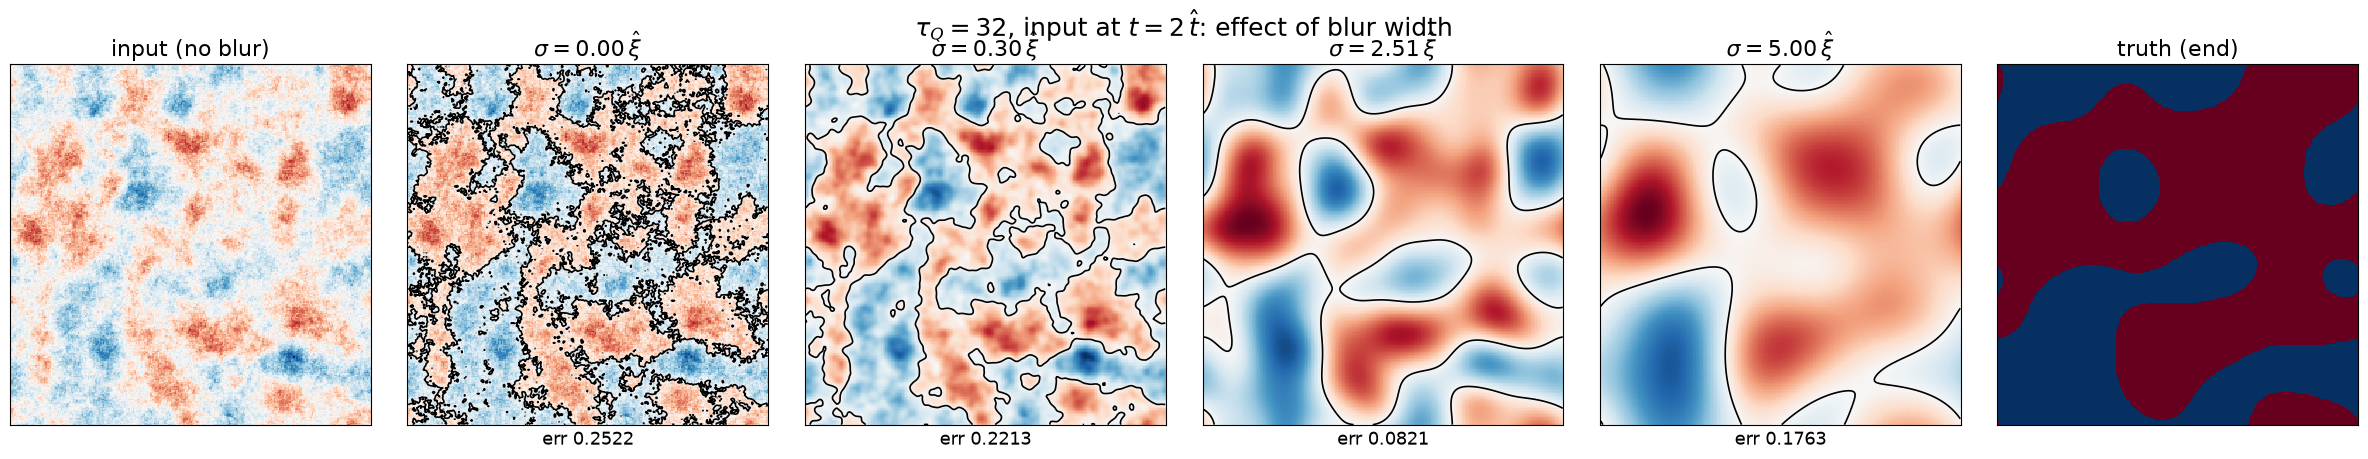

In [18]:
# ---- inputs ----
T_DEMO   = 2                                    # input time, units of t_hat (one of T_B)
SIG_DEMO = [0,0.3, sig_best_b[4], 5.0]            # low, best, high blur width, units of xi_hat
FONTSIZE = 16

X, t_used = an.snapshot_at(d, T_DEMO)
x = X[s]                                        # same test sample as the cell above

fig, axes = plt.subplots(1, len(SIG_DEMO) + 2, figsize=(4 * (len(SIG_DEMO) + 2), 4.4))

v = np.abs(x).max()
axes[0].imshow(x, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
axes[0].set_title("input (no blur)", fontsize=FONTSIZE)

for ax, m in zip(axes[1:-1], SIG_DEMO):
    xb = np.fft.irfft2(np.fft.rfft2(x) * np.exp(-K2 * (m * xi_hat)**2 / 2), s=(N, N))
    vb = np.abs(xb).max()
    ax.imshow(xb, cmap="RdBu_r", vmin=-vb, vmax=vb, interpolation="nearest")
    ax.contour(xb, levels=[0], colors="k", linewidths=1.2)
    ax.set_title(rf"$\sigma = {m:.2f}\,\hat\xi$", fontsize=FONTSIZE)
    ax.set_xlabel(f"err {((xb > 0) != Y).mean():.4f}", fontsize=FONTSIZE - 3)

axes[-1].imshow(Y, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
axes[-1].set_title("truth (end)", fontsize=FONTSIZE)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(rf"$\tau_Q = {TAU_B}$, input at $t = {t_used:g}\,\hat t$: effect of blur width", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig(f"../figures/2d/blur_widths_demo_tau{TAU_B}.png", dpi=150)
plt.show()

Above, we show the effect of increasing the value of $\sigma$. As $\sigma$ increases, we can see the error decreases non-monotomically as we tune the filter (which makes sense, if we throw out wavelengths longer than $1/\xi_{KZ}$ we're losing crucial information!) 

The error, luckily for us, is convex w.r.t. $\sigma$ and the kernel has only one free parameter, Meaning we can simply scan over the one dimensional curve of the error and choose the minimum as our optimal $\sigma$.

t=0: persistence err = 0.4509   best blur: sigma = 3.19 xi_hat, err = 0.2675
t=0.5: persistence err = 0.4213   best blur: sigma = 3.29 xi_hat, err = 0.1832
t=1: persistence err = 0.3830   best blur: sigma = 3.24 xi_hat, err = 0.1185
t=2: persistence err = 0.2647   best blur: sigma = 2.96 xi_hat, err = 0.0546
t=4: persistence err = 0.1275   best blur: sigma = 2.51 xi_hat, err = 0.0491
t=5: persistence err = 0.0996   best blur: sigma = 2.26 xi_hat, err = 0.0487
t=6: persistence err = 0.0793   best blur: sigma = 2.54 xi_hat, err = 0.0201
t=7: persistence err = 0.0558   best blur: sigma = 2.26 xi_hat, err = 0.0101
t=8: persistence err = 0.0348   best blur: sigma = 1.88 xi_hat, err = 0.0038
t=9: persistence err = 0.0164   best blur: sigma = 1.37 xi_hat, err = 0.0009


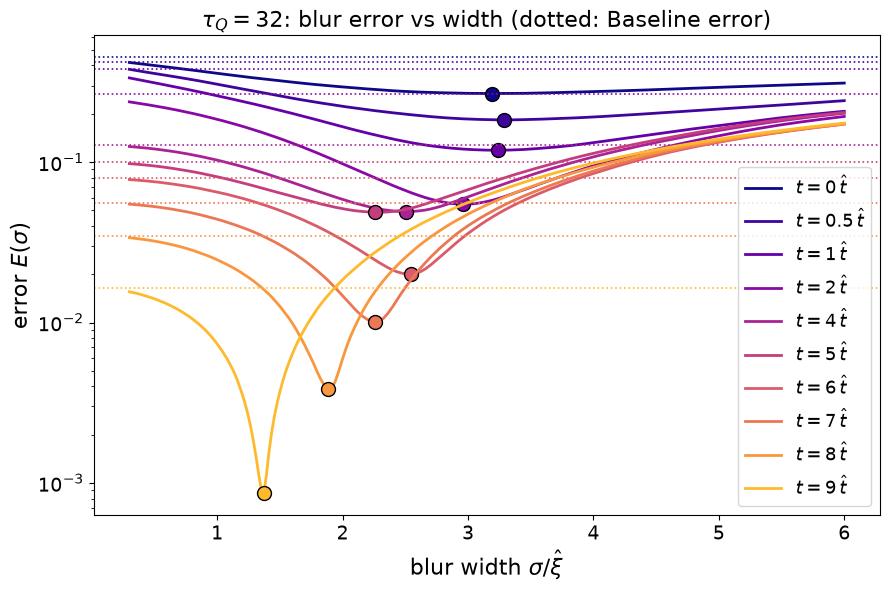

In [21]:
# ---- inputs ----
TAU_B    = 32
T_B      = [0,1/2,1,2, 4,5,6,7,8,9]                   # input times, units of t_hat
SIG_B    = np.geomspace(0.3, 6, 200)         # blur widths, units of xi_hat (dense)
TARGET   = "y_end"
FONTSIZE = 16

d = an.load_chunk(TAU_B, chunk=0)
Yb = d[TARGET]
N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])
kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky = 2 * np.pi * np.fft.rfftfreq(N, d=dx)
K2 = kx[:, None]**2 + ky[None, :]**2

E_b, sig_best_b, err_best_b, pers_b = {}, {}, {}, {}
for t in T_B:
    X, _ = an.snapshot_at(d, t)
    F = np.fft.rfft2(X, axes=(-2, -1))
    E_b[t] = np.array([((np.fft.irfft2(F * np.exp(-K2 * (m * xi_hat)**2 / 2), s=(N, N), axes=(-2, -1)) > 0) != Yb).mean()
                       for m in SIG_B])
    j = int(np.argmin(E_b[t]))
    sig_best_b[t], err_best_b[t] = SIG_B[j], E_b[t][j]
    pers_b[t] = ((X > 0) != Yb).mean()
    print(f"t={t}: persistence err = {pers_b[t]:.4f}   best blur: sigma = {SIG_B[j]:.2f} xi_hat, err = {E_b[t][j]:.4f}")

colors = plt.cm.plasma(np.linspace(0, 0.85, len(T_B)))
plt.figure(figsize=(9, 6))
for t, c in zip(T_B, colors):
    plt.semilogy(SIG_B, E_b[t], "-", color=c, lw=2, label=rf"$t = {t}\,\hat t$")
    plt.semilogy(sig_best_b[t], err_best_b[t], "o", color=c, ms=10, mec="k")
    plt.axhline(pers_b[t], color=c, ls=":", lw=1.2)                  # sigma -> 0 (persistence)
plt.xlabel(r"blur width $\sigma/\hat\xi$", fontsize=FONTSIZE)
plt.ylabel(r"error $E(\sigma)$", fontsize=FONTSIZE)
plt.title(rf"$\tau_Q = {TAU_B}$: blur error vs width (dotted: Baseline error)", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 3)
plt.tight_layout()
plt.savefig(f"../figures/2d/blur_fit_tau{TAU_B}.png", dpi=150)
plt.show()

We can see above that at early times, the filter doesnt really change its position that much. Then there is some period of time wheere it begins to change rapidly, then it begins to narrow more. As it narrows, we see the error gest rudced much more greatly.

KeyboardInterrupt: 

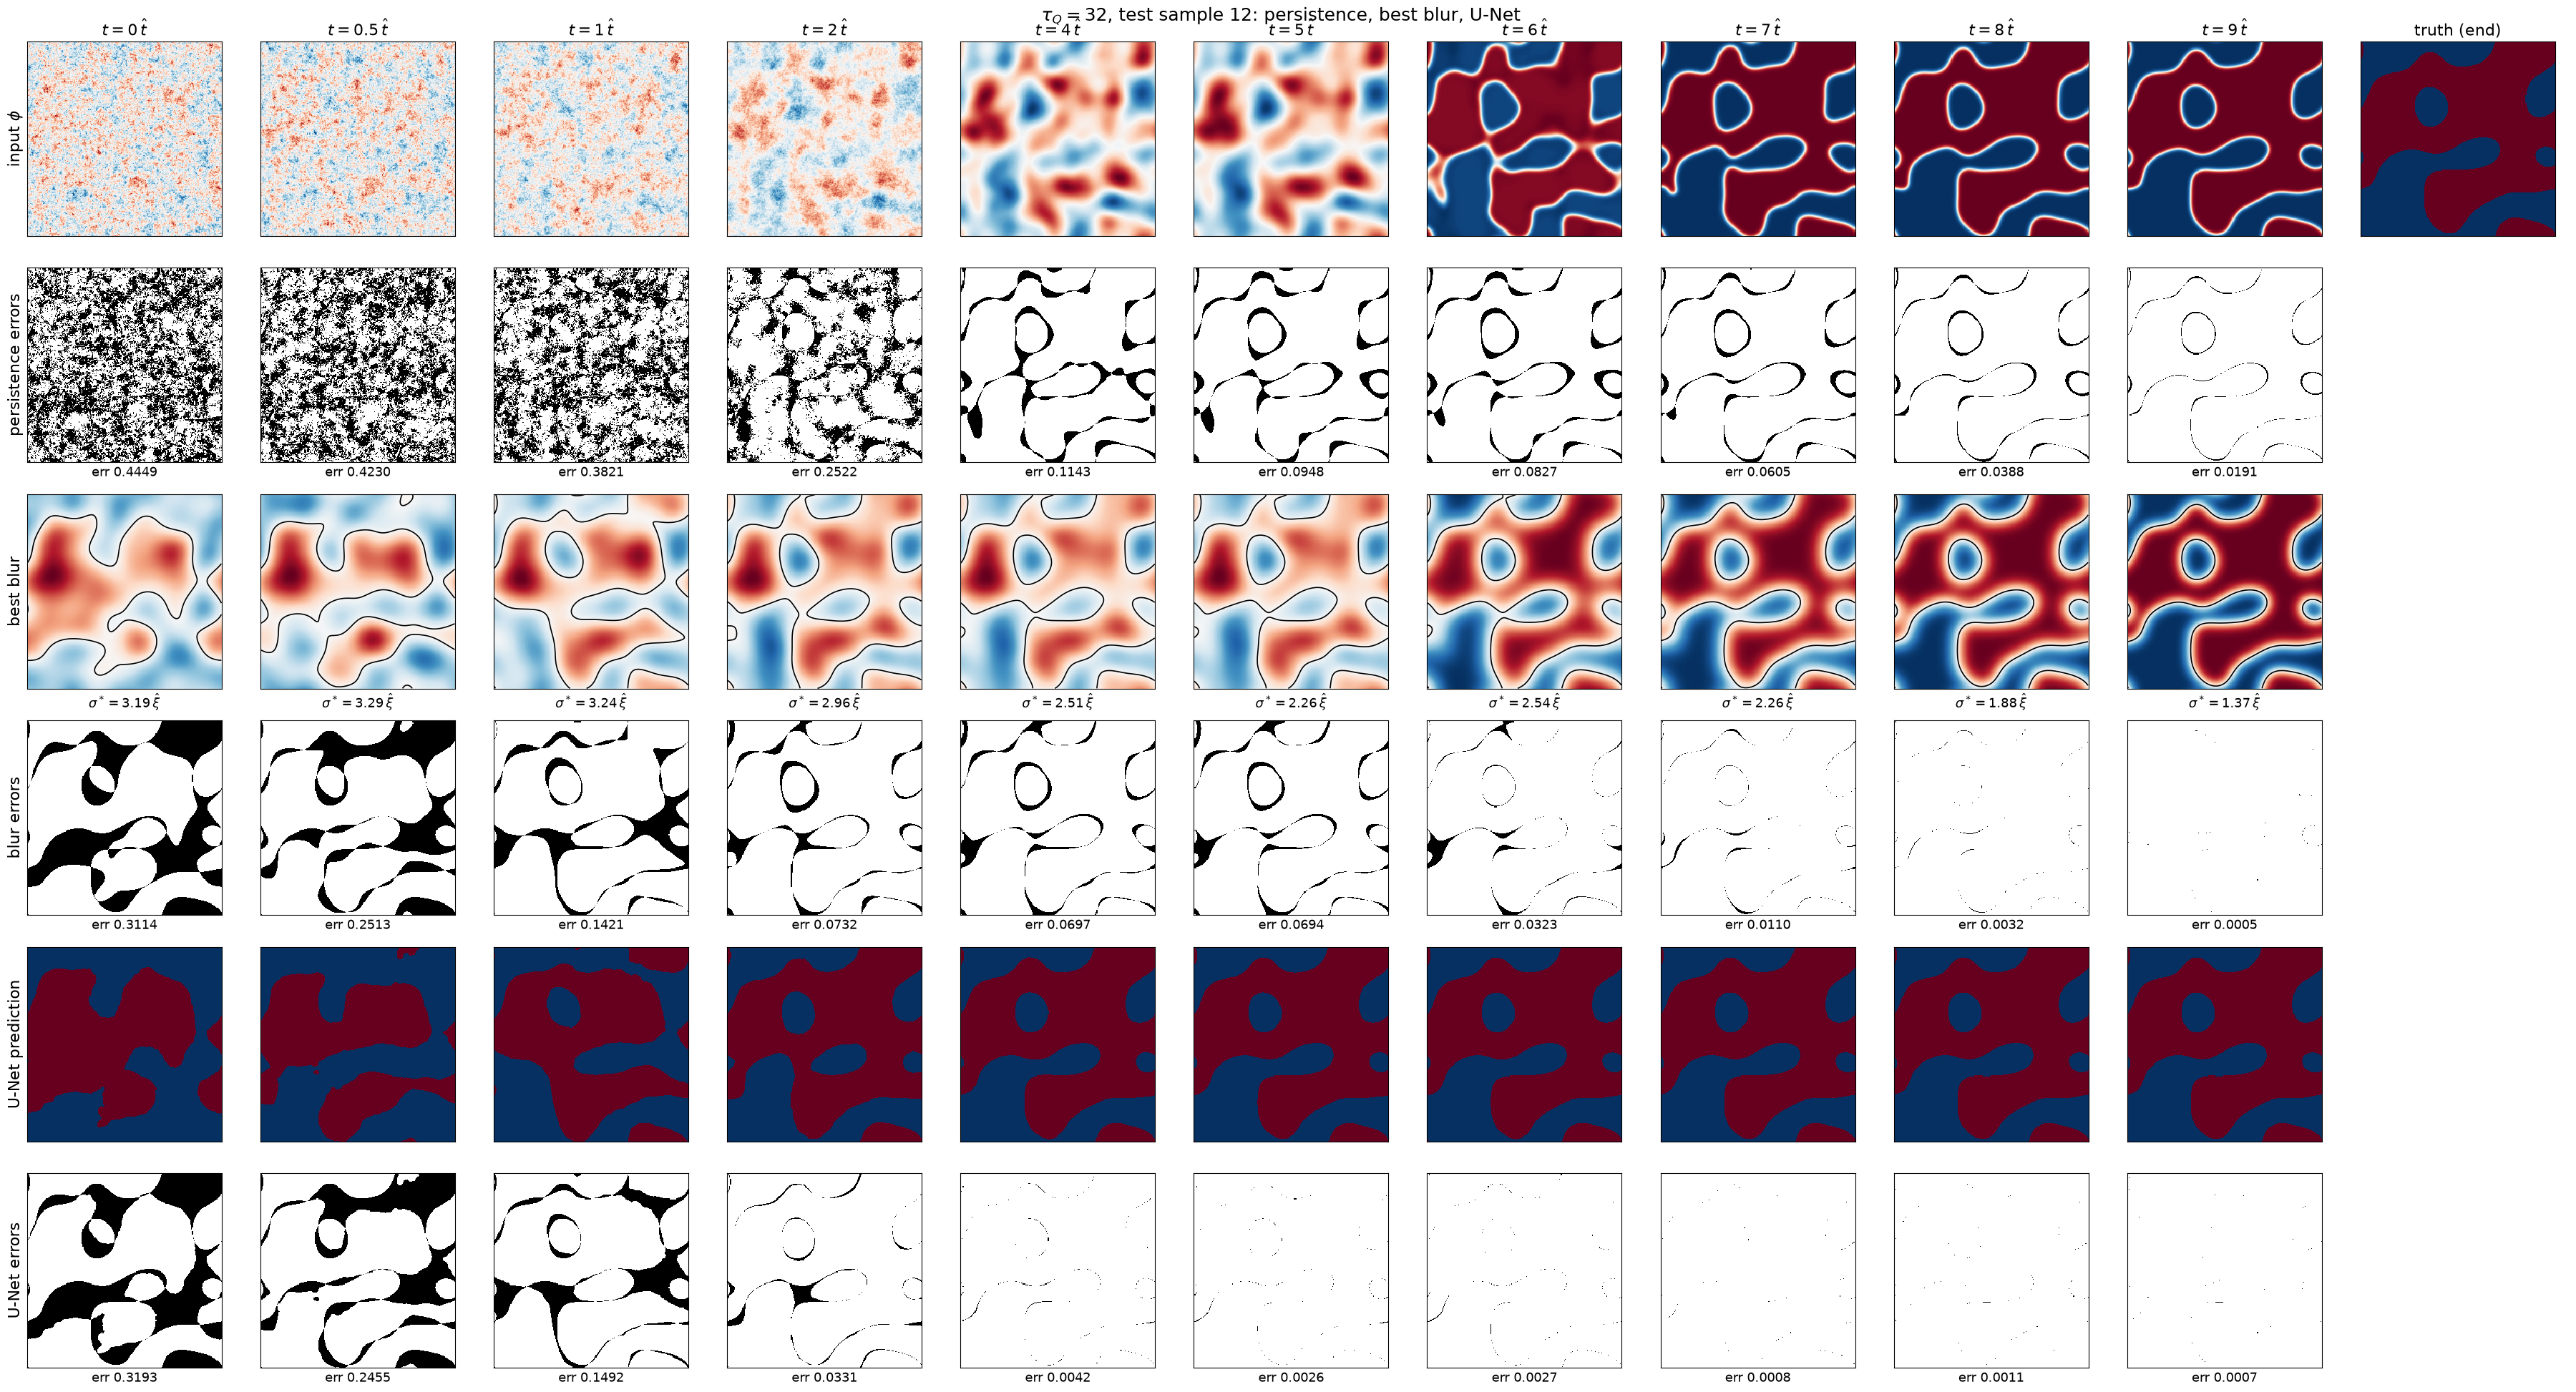

In [ ]:
# ---- inputs ----
PICK     = 0                                  # which test-split sample in chunk 0
SEED     = 0                                  # split seed used in training

# test-split sample in chunk 0 (same split as training)
n_total  = an.load_results(TAU_B, target=TARGET)[0]["n_samples"]
test_idx = np.random.default_rng(SEED).permutation(n_total)[: n_total // 10]
s        = int(np.sort(test_idx[test_idx < len(Yb)])[PICK])
Y        = Yb[s]

rows = ["input $\\phi$", "persistence errors", "best blur", "blur errors", "U-Net prediction", "U-Net errors"]
fig, axes = plt.subplots(len(rows), len(T_B) + 1, figsize=(3.3 * (len(T_B) + 1), 3.3 * len(rows)), squeeze=False)

for col, t in enumerate(T_B):
    X, t_used = an.snapshot_at(d, t)
    x  = X[s]
    xb = np.fft.irfft2(np.fft.rfft2(x) * np.exp(-K2 * (sig_best_b[t] * xi_hat)**2 / 2), s=(N, N))
    model, meta = an.load_model(os.path.join(an.RESULTS, f"tau{TAU_B}_that{t:g}_{TARGET}"))
    pred = an.predict(model, X[[s]], meta["scale"])[0]

    v, vb = np.abs(x).max(), np.abs(xb).max()
    axes[0, col].imshow(x,  cmap="RdBu_r", vmin=-v,  vmax=v,  interpolation="nearest")
    axes[1, col].imshow((x > 0) != Y, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    axes[2, col].imshow(xb, cmap="RdBu_r", vmin=-vb, vmax=vb, interpolation="nearest")
    axes[2, col].contour(xb, levels=[0], colors="k", linewidths=1.2)
    axes[3, col].imshow((xb > 0) != Y, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    axes[4, col].imshow(pred, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
    axes[5, col].imshow(pred != Y, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")

    axes[0, col].set_title(rf"$t = {t_used:g}\,\hat t$", fontsize=FONTSIZE)
    axes[1, col].set_xlabel(f"err {((x > 0) != Y).mean():.4f}", fontsize=FONTSIZE - 3)
    axes[2, col].set_xlabel(rf"$\sigma^* = {sig_best_b[t]:.2f}\,\hat\xi$", fontsize=FONTSIZE - 3)
    axes[3, col].set_xlabel(f"err {((xb > 0) != Y).mean():.4f}", fontsize=FONTSIZE - 3)
    axes[5, col].set_xlabel(f"err {(pred != Y).mean():.4f}", fontsize=FONTSIZE - 3)

axes[0, -1].imshow(Y, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
axes[0, -1].set_title("truth (end)", fontsize=FONTSIZE)
for r in range(1, len(rows)):
    axes[r, -1].axis("off")
for r, lab in enumerate(rows):
    axes[r, 0].set_ylabel(lab, fontsize=FONTSIZE)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(rf"$\tau_Q = {TAU_B}$, test sample {s}: persistence, best blur, U-Net", fontsize=FONTSIZE + 2)
plt.tight_layout()a
plt.savefig(f"../figures/2d/persistence_blur_unet_tau{TAU_B}.png", dpi=150)
plt.show()

Above we compare the predictions 

In [8]:
import os, glob, inspect
print("RESULTS path:", an.RESULTS, "  exists:", os.path.exists(an.RESULTS))
print("json files:", len(glob.glob(os.path.join(an.RESULTS, "*.json"))))
print(inspect.signature(an.load_results))

RESULTS path: /Users/kristian/Research/MachineLearningKZ/notebooks/../src/../results/v2   exists: True
json files: 48
(tau, target='y_end', results_dir='/Users/kristian/Research/MachineLearningKZ/notebooks/../src/../results/v2')


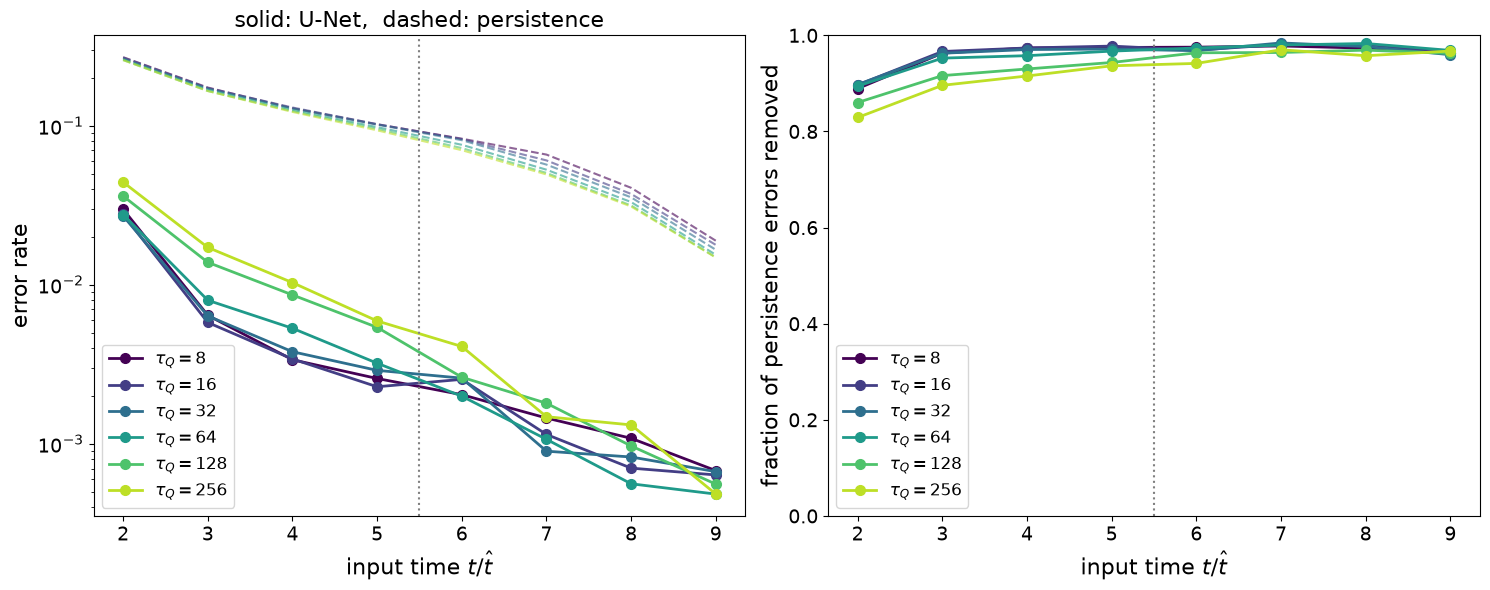

In [9]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
TARGET   = "y_end"
FONTSIZE = 16

colors = plt.cm.viridis(np.linspace(0, 0.9, len(TAUS)))
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for tau, c in zip(TAUS, colors):
    res = an.load_results(tau, target=TARGET)
    if not res:
        print(f"tau={tau}: no results found")
        continue
    t, eb, em = an.as_arrays(res)                     # t in units of t_hat; error = 1 - accuracy
    ax[0].semilogy(t, em, "o-", color=c, ms=7, lw=2, label=rf"$\tau_Q = {tau}$")
    ax[0].semilogy(t, eb, "--", color=c, lw=1.5, alpha=0.6)
    ax[1].plot(t, 1 - em / eb, "o-", color=c, ms=7, lw=2, label=rf"$\tau_Q = {tau}$")

ax[0].set_ylabel("error rate", fontsize=FONTSIZE)
ax[0].set_title("solid: U-Net,  dashed: persistence", fontsize=FONTSIZE)
ax[1].set_ylabel("fraction of persistence errors removed", fontsize=FONTSIZE)
ax[1].set_ylim(0, 1)

for a in ax:
    a.set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
    a.axvline(5.5, color="grey", ls=":", lw=1.5)      # approx formation time
    a.tick_params(labelsize=FONTSIZE - 2)
    a.legend(fontsize=FONTSIZE - 4)

plt.tight_layout()
plt.savefig("../figures/2d/error_vs_that.png", dpi=150)
plt.show()

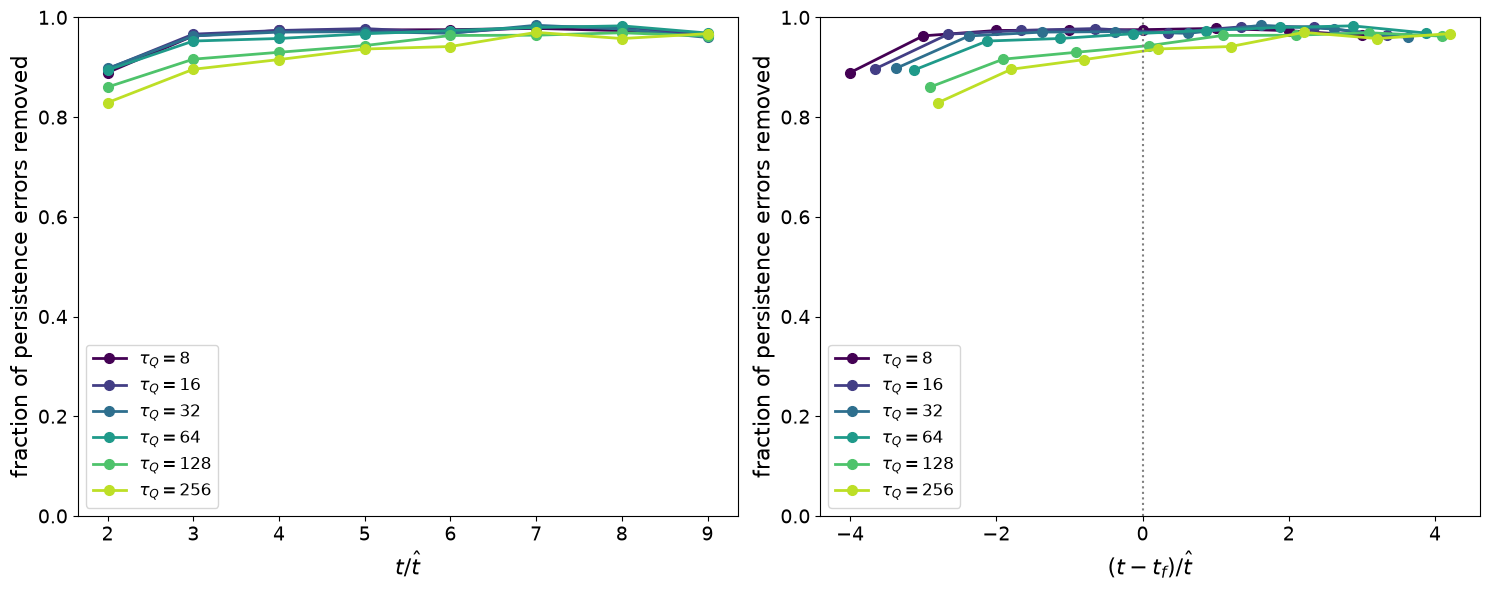

In [10]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
TARGET   = "y_end"
SCALING  = "../results/kz_scaling.json"
FONTSIZE = 16

# formation time per tau, units of t_hat
r  = json.load(open(SCALING))["results"]
tf = {x["tau"]: x["t_f"] / x["t_hat"] for x in r}

colors = plt.cm.viridis(np.linspace(0, 0.9, len(TAUS)))
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for tau, c in zip(TAUS, colors):
    res = an.load_results(tau, target=TARGET)
    t, eb, em = an.as_arrays(res)
    ax[0].plot(t,            1 - em / eb, "o-", color=c, ms=7, lw=2, label=rf"$\tau_Q = {tau}$")
    ax[1].plot(t - tf[tau],  1 - em / eb, "o-", color=c, ms=7, lw=2, label=rf"$\tau_Q = {tau}$")

ax[0].set_xlabel(r"$t/\hat t$", fontsize=FONTSIZE)
ax[1].set_xlabel(r"$(t - t_f)/\hat t$", fontsize=FONTSIZE)
ax[1].axvline(0, color="grey", ls=":", lw=1.5)
for a in ax:
    a.set_ylabel("fraction of persistence errors removed", fontsize=FONTSIZE)
    a.set_ylim(0, 1)
    a.tick_params(labelsize=FONTSIZE - 2)
    a.legend(fontsize=FONTSIZE - 4)

plt.tight_layout()
plt.show()

In [ ]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
import src.analysis as an

TAU = 128
res = an.load_results(TAU)
ok  = [r for r in res if r["has_ckpt"]]          # runs we can actually load

print(f"tau={TAU}: {len(res)} results, {len(ok)} with checkpoints")
print("times:", [round(r["t_used"], 1) for r in res])
if len(ok) < len(res):
    print("missing .pt for:", [round(r["t_used"],1) for r in res if not r["has_ckpt"]])

tau=128: 9 results, 4 with checkpoints
times: [-64.0, -32.0, 0.0, 12.8, 25.6, 38.4, 51.2, 64.0, 96.0]
missing .pt for: [25.6, 38.4, 51.2, 64.0, 96.0]


In [1]:
# ---- inputs ----
TAU      = 64
T_FRACS  = [0.1, 0.25, 0.5, 1.0]   # times to show, in units of tau (eps = t/tau)
SAMPLE   = 0
FONTSIZE = 16

d = an.load_chunk(TAU)
f_final = d["phi_final"][SAMPLE]

fig, axes = plt.subplots(1, len(T_FRACS), figsize=(5 * len(T_FRACS), 5.5))

for ax, frac in zip(axes, T_FRACS):
    snaps_t, t_used = an.snapshot_at(d, frac * TAU)
    f = snaps_t[SAMPLE]
    v = np.abs(f).max()                                   # per-panel scale: amplitude grows over the quench
    ax.imshow(f, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
    ax.contour(f,       levels=[0], colors="k",    linewidths=2)   # walls at time t
    ax.contour(f_final, levels=[0], colors="green", linewidths=4, linestyles="-")  # final walls
    ax.set_title(rf"$\epsilon = t/\tau = {t_used / TAU:.2f}$", fontsize=FONTSIZE)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(rf"$\tau_Q = {TAU}$:  black = walls at $t$,  gold dashed = final walls",
             fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig("../figures/2d/walls_vs_final.png", dpi=150)
plt.show()

NameError: name 'an' is not defined

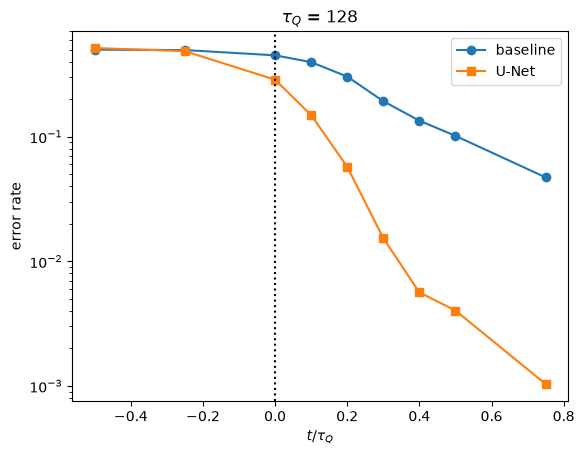

threshold 0.4:  t*/tau = -0.142
threshold 0.3:  t*/tau = -0.016
threshold 0.25:  t*/tau = 0.027
threshold 0.2:  t*/tau = 0.063


In [26]:
t, eb, em = an.as_arrays(res)

plt.semilogy(t/TAU, eb, "o-", label="baseline")
plt.semilogy(t/TAU, em, "s-", label="U-Net")
plt.axvline(0, color="k", ls=":")
plt.xlabel("$t/\\tau_Q$"); plt.ylabel("error rate")
plt.title(f"$\\tau_Q$ = {TAU}"); plt.legend()
plt.show()

for thr in [0.4, 0.3, 0.25, 0.2]:
    print(f"threshold {thr}:  t*/tau = {an.t_star(res, TAU, thr):.3f}")

In [27]:
d  = an.load_chunk(TAU)
xi = an.correlation_length(d["phi_final"])
wl = an.wall_length(d["phi_final"])
print(f"xi   = {xi.mean():5.1f} ± {xi.std():.1f} sites   (box = 128)")
print(f"wall = {wl.mean():5.0f} ± {wl.std():.0f}")

xi   =  28.9 ± 3.9 sites   (box = 128)
wall =   131 ± 64


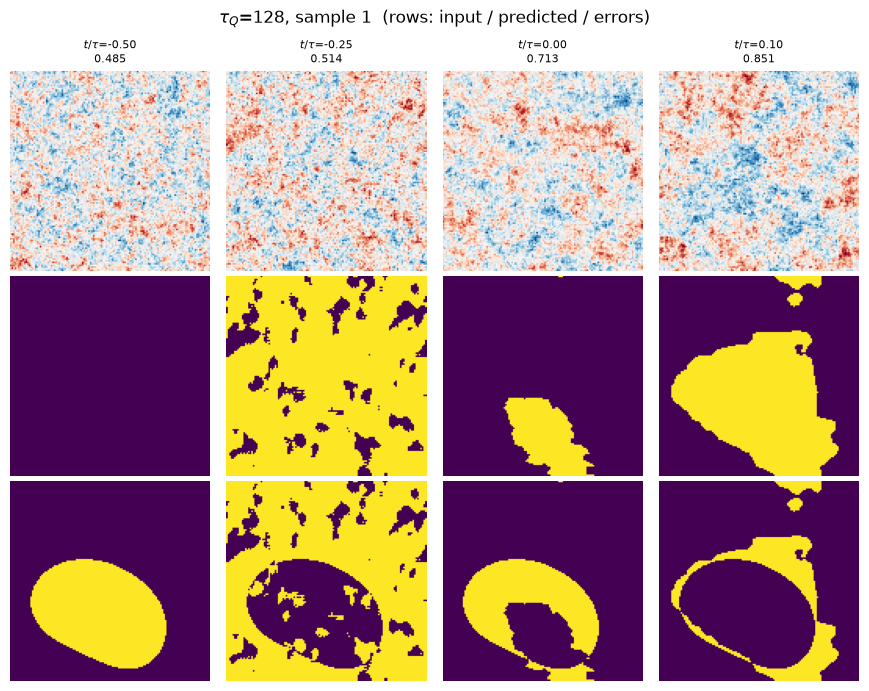

In [29]:
SAMPLE = 1
Y = (d["phi_final"] > 0)[SAMPLE]

n = len(ok)
fig, axes = plt.subplots(3, n, figsize=(2.2*n, 7))
for col, r in enumerate(ok):
    model, meta = an.load_model(r["tag"])
    X, t_used = an.snapshot_at(d, meta["t_used"])
    p = an.predict(model, X, meta["scale"])[SAMPLE]

    axes[0, col].imshow(X[SAMPLE], cmap="RdBu")
    axes[0, col].set_title(f"$t/\\tau$={t_used/TAU:.2f}\n{meta['test_acc']:.3f}", fontsize=8)
    axes[1, col].imshow(p)
    axes[2, col].imshow(p != Y)
for a in axes.ravel(): a.axis("off")
plt.suptitle(f"$\\tau_Q$={TAU}, sample {SAMPLE}  (rows: input / predicted / errors)")
plt.tight_layout(); plt.show()

In [31]:
TAUS  = [32, 64, 128]
THRS  = [0.4, 0.3, 0.25, 0.2]

allres = {}
tstar  = {thr: [] for thr in THRS}

print(f"{'tau':>5} {'n':>3} " + " ".join(f"{thr:>8}" for thr in THRS))
for tau in TAUS:
    res = an.load_results(tau)
    allres[tau] = res
    row = [an.t_star(res, tau, thr) for thr in THRS]
    for thr, v in zip(THRS, row):
        tstar[thr].append(v)
    print(f"{tau:>5} {len(res):>3} " + " ".join(f"{v:>8.3f}" for v in row))

  tau   n      0.4      0.3     0.25      0.2
   32   9   -0.205   -0.038    0.039    0.113
   64   9   -0.168   -0.050    0.009    0.066
  128   9   -0.142   -0.016    0.027    0.063


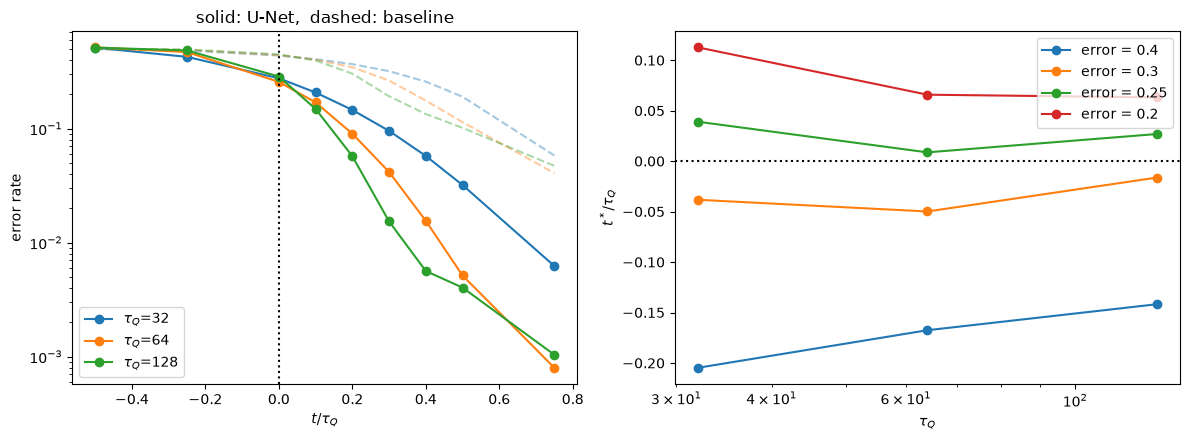

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: all error curves, rescaled time
for tau in TAUS:
    t, eb, em = an.as_arrays(allres[tau])
    axes[0].semilogy(t/tau, em, "o-",  label=f"$\\tau_Q$={tau}")
    axes[0].semilogy(t/tau, eb, "--", color=axes[0].lines[-1].get_color(), alpha=0.4)
axes[0].axvline(0, color="k", ls=":")
axes[0].set_xlabel("$t/\\tau_Q$"); axes[0].set_ylabel("error rate")
axes[0].set_title("solid: U-Net,  dashed: baseline")
axes[0].legend()

# right: t* vs tau, one line per threshold
for thr in THRS:
    axes[1].plot(TAUS, tstar[thr], "o-", label=f"error = {thr}")
axes[1].set_xscale("log")
axes[1].axhline(0, color="k", ls=":")
axes[1].set_xlabel("$\\tau_Q$"); axes[1].set_ylabel("$t^*/\\tau_Q$")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/collapse_and_tstar.png", dpi=150)
plt.show()

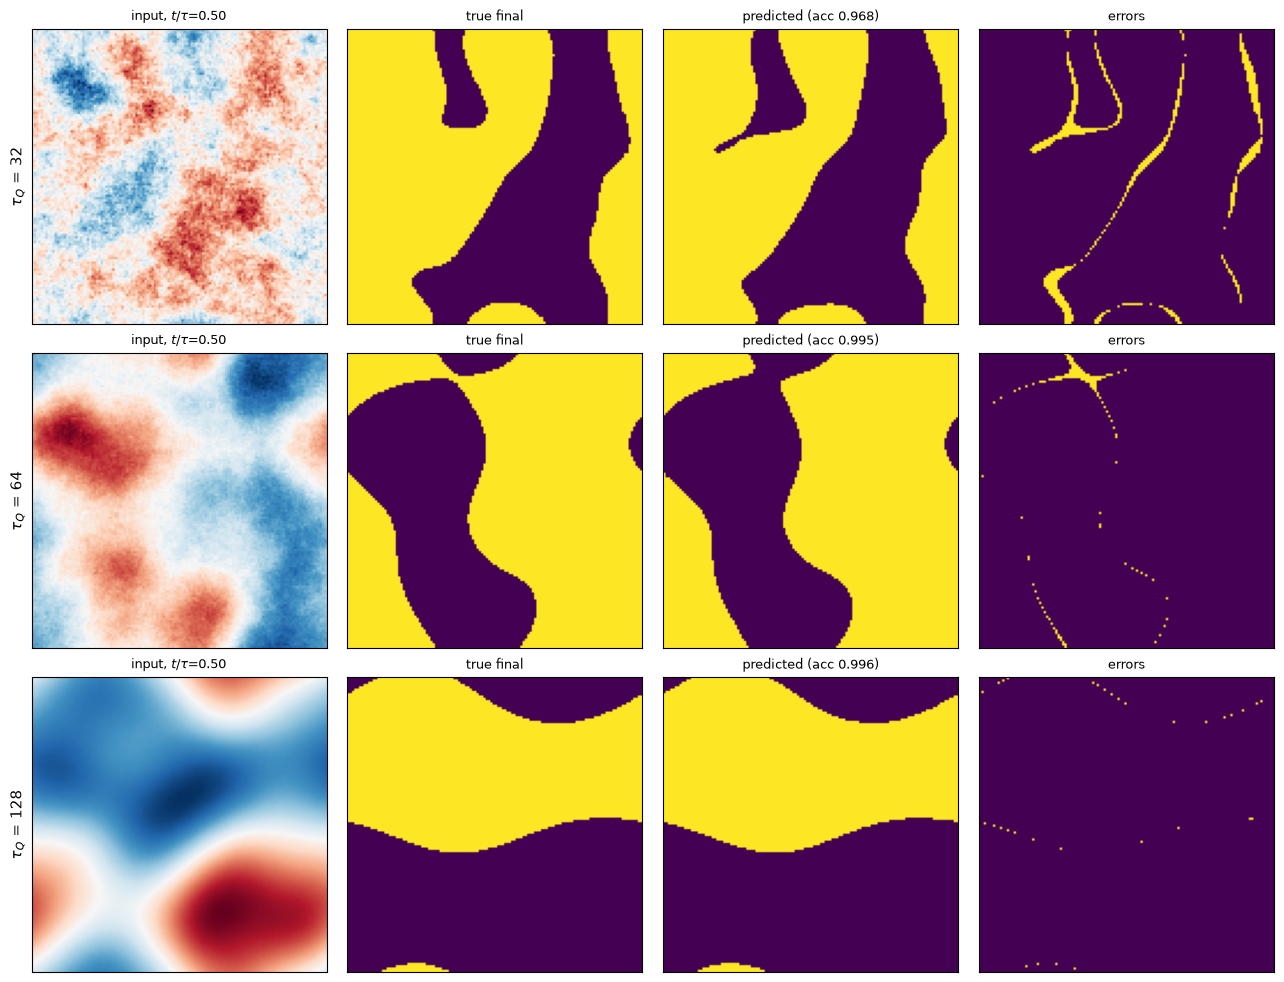

In [41]:
T_FRAC = 0.5          # t/tau to look at
SAMPLE = 0

fig, axes = plt.subplots(len(TAUS), 4, figsize=(13, 3.3*len(TAUS)))

for row, tau in enumerate(TAUS):
    d   = an.load_chunk(tau)
    res = [r for r in an.load_results(tau) if r["has_ckpt"]]
    # closest trained model to T_FRAC
    r   = min(res, key=lambda r: abs(r["t_used"]/tau - T_FRAC))

    model, meta = an.load_model(r["tag"])
    X, t_used   = an.snapshot_at(d, meta["t_used"])
    pred = an.predict(model, X, meta["scale"])[SAMPLE]
    Y    = (d["phi_final"] > 0)[SAMPLE]

    axes[row, 0].imshow(X[SAMPLE], cmap="RdBu")
    axes[row, 1].imshow(Y)
    axes[row, 2].imshow(pred)
    axes[row, 3].imshow(pred != Y)

    axes[row, 0].set_ylabel(f"$\\tau_Q$ = {tau}", fontsize=11)
    axes[row, 0].set_title(f"input, $t/\\tau$={t_used/tau:.2f}", fontsize=9)
    axes[row, 1].set_title("true final", fontsize=9)
    axes[row, 2].set_title(f"predicted (acc {meta['test_acc']:.3f})", fontsize=9)
    axes[row, 3].set_title("errors", fontsize=9)
    for a in axes[row]:
        a.set_xticks([]); a.set_yticks([])

plt.tight_layout()
plt.savefig(f"../figures/across_tau_frac{T_FRAC}.png", dpi=150)
plt.show()

In [39]:
for tau in TAUS:
    have = [round(r["t_used"]/tau, 2) for r in an.load_results(tau) if r["has_ckpt"]]
    print(tau, have)

32 [-0.5, -0.25, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75]
64 [-0.5, -0.25, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75]
128 [-0.5, -0.25, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75]


In [38]:
qstat -u kmunnik
ls /projectnb/fheating/kmunnik/MachineLearningKZ/results/*.pt | wc -l

SyntaxError: invalid syntax (1791727937.py, line 1)

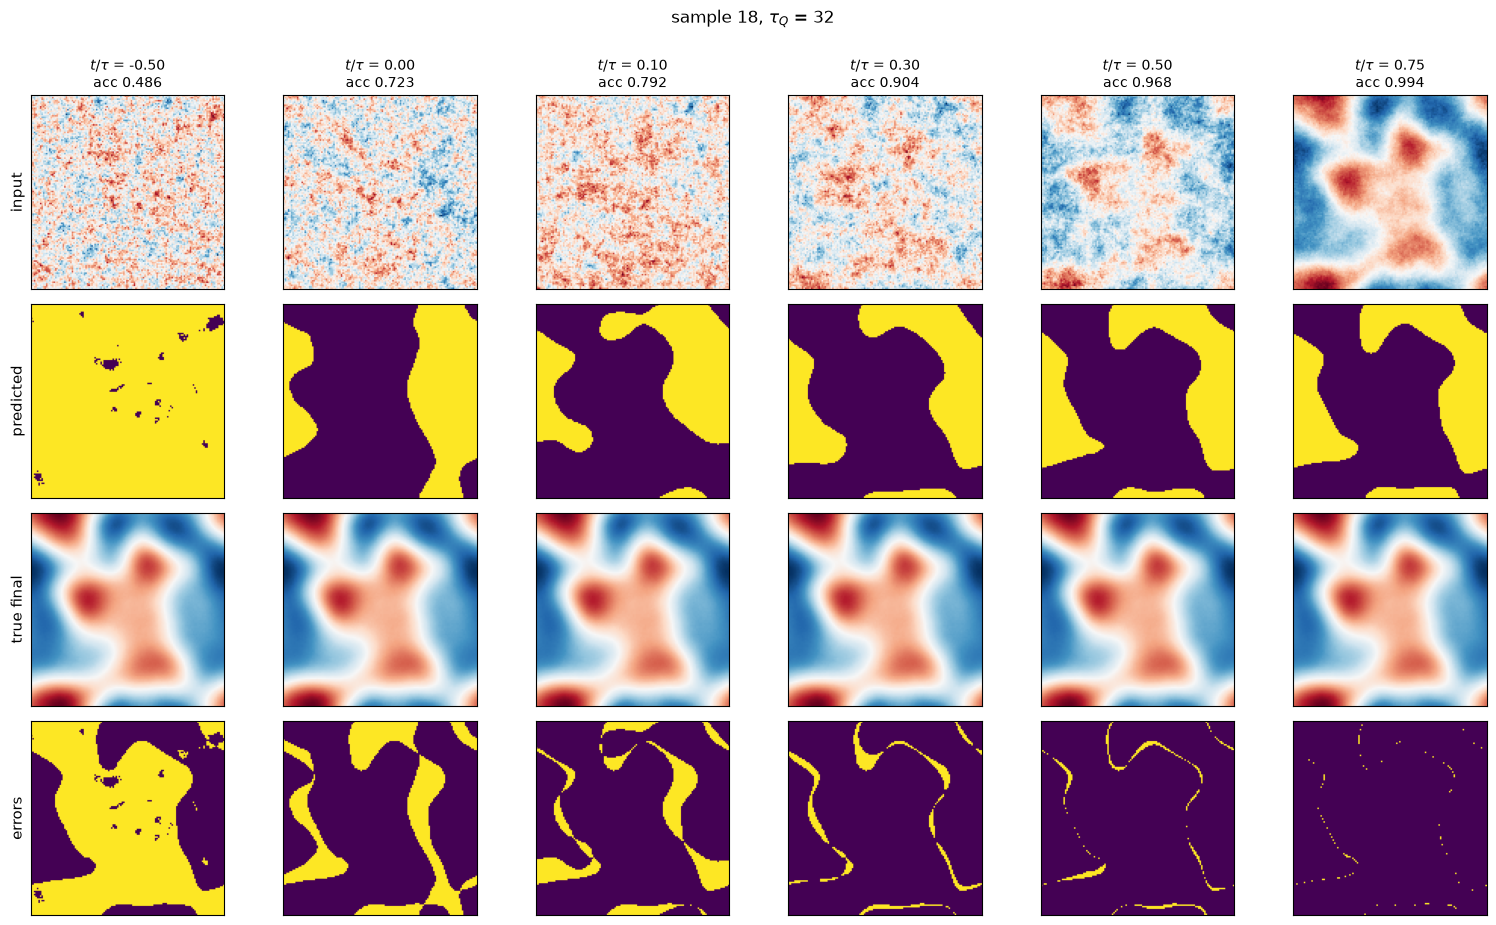

In [ ]:
import sys; sys.path.insert(0, "..")
import glob, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import src.kz_ml as kzml

SAMPLE = 18
TAU    = 32
WANT   = [-0.5, 0.0, 0.1, 0.3, 0.5, 0.75]

tags = sorted(
    (json.load(open(f))["t_used"], f.replace(".json", ""))
    for f in glob.glob(f"../results/tau{TAU}_t*.json")
    if glob.glob(f.replace(".json", ".pt"))
    and any(abs(json.load(open(f))["t_used"]/TAU - w) < 1e-6 for w in WANT)
)

missing = [w for w in WANT if not any(abs(t/TAU - w) < 1e-6 for t, _ in tags)]
if missing:
    print("no checkpoint for t/tau =", missing)

d = np.load(f"../data/2D_tau{TAU}/chunk_000.npz")
Y = (d["phi_final"] > 0)[SAMPLE]

n = len(tags)
fig, axes = plt.subplots(4, n, figsize=(2.6*n, 9.2), squeeze=False)

for col, (t_used, tag) in enumerate(tags):
    r     = json.load(open(tag + ".json"))
    model = kzml.UNet()
    model.load_state_dict(torch.load(tag + ".pt", map_location="cpu"))
    model.eval()

    i = int(np.argmin(np.abs(d["snap_times"] - t_used)))
    x = d["snaps"][SAMPLE, i]

    with torch.no_grad():
        pred = (model(torch.from_numpy(x[None, None] / r["scale"])) > 0).numpy()[0, 0]

    axes[0, col].imshow(x, cmap="RdBu")
    axes[0, col].set_title(f"$t/\\tau$ = {t_used/TAU:.2f}\nacc {r['test_acc']:.3f}", fontsize=10)
    axes[1, col].imshow(pred)
    axes[2, col].imshow(d["phi_final"][SAMPLE], cmap="RdBu")
    axes[3, col].imshow(pred != Y)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
for row, lab in enumerate(["input", "predicted", "true final", "errors"]):
    axes[row, 0].set_ylabel(lab, fontsize=11)

plt.suptitle(f"sample {SAMPLE}, $\\tau_Q$ = {TAU}", y=1.0)
plt.tight_layout()
plt.savefig(f"../figures/evolution_tau{TAU}_s{SAMPLE}.png", dpi=150)
plt.show()

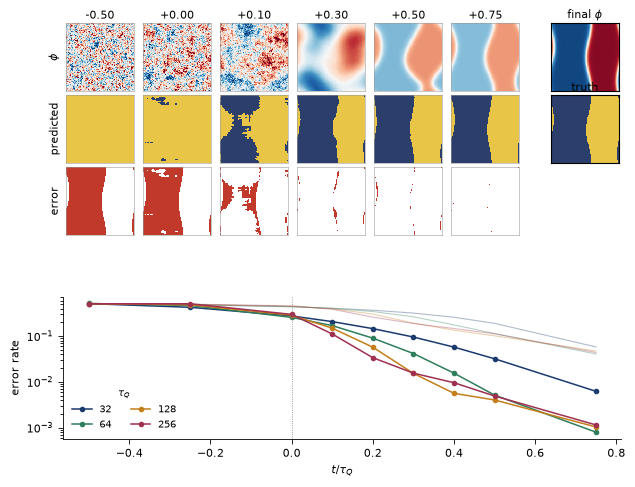

In [19]:
import sys; sys.path.insert(0, "..")
import glob, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib.colors import ListedColormap
import torch
import src.kz_ml as kzml
import src.analysis as an

SAMPLE, TAU = 12, 256
WANT = [-0.5, 0.0, 0.1, 0.3, 0.5, 0.75]

plt.rcParams.update({
    "font.size": 8, "font.family": "sans-serif",
    "axes.linewidth": 0.6, "xtick.major.width": 0.6,
    "ytick.major.width": 0.6, "savefig.bbox": "tight",
})

DOM = ListedColormap(["#2c3e6b", "#e8c547"])      # down / up
ERR = ListedColormap([(0, 0, 0, 0), "#c0392b"])   # transparent / error

tags = sorted(
    (json.load(open(f))["t_used"], f.replace(".json", ""))
    for f in glob.glob(f"../results/tau{TAU}_t*.json")
    if glob.glob(f.replace(".json", ".pt"))
    and any(abs(json.load(open(f))["t_used"]/TAU - w) < 1e-6 for w in WANT)
)

d = np.load(f"../data/2D_tau{TAU}/chunk_000.npz")
Y = (d["phi_final"] > 0)[SAMPLE]
n = len(tags)

fig = plt.figure(figsize=(7.2, 5.4))
outer = gs.GridSpec(2, 1, height_ratios=[3, 2], hspace=0.35, figure=fig)
top   = gs.GridSpecFromSubplotSpec(3, n + 2, subplot_spec=outer[0],
                                   width_ratios=[1]*n + [0.25, 1],
                                   wspace=0.06, hspace=0.06)

for col, (t_used, tag) in enumerate(tags):
    r = json.load(open(tag + ".json"))
    model = kzml.UNet()
    model.load_state_dict(torch.load(tag + ".pt", map_location="cpu"))
    model.eval()

    i = int(np.argmin(np.abs(d["snap_times"] - t_used)))
    x = d["snaps"][SAMPLE, i]
    with torch.no_grad():
        pred = (model(torch.from_numpy(x[None, None] / r["scale"])) > 0).numpy()[0, 0]

    v = 2.5 * x.std()
    for row, (img, cm, kw) in enumerate([
            (x, "RdBu_r", dict(vmin=-v, vmax=v)),
            (pred, DOM, dict(vmin=0, vmax=1)),
            (pred != Y, ERR, dict(vmin=0, vmax=1))]):
        ax = fig.add_subplot(top[row, col])
        ax.imshow(img, cmap=cm, interpolation="nearest", **kw)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_linewidth(0.4); s.set_color("0.6")
        if row == 0:
            ax.set_title(f"{t_used/TAU:+.2f}", fontsize=8, pad=3)
        if row == 1:
            ax.text(0.5, -0.09, f"{r['test_acc']:.3f}", fontsize=7,
                    ha="center", va="top", transform=ax.transAxes, color="0.35")
        if col == 0:
            ax.set_ylabel(["$\\phi$", "predicted", "error"][row], fontsize=8)

# reference panels, set apart: continuous field above binary truth
v_f = 1.1 * np.abs(d["phi_final"][SAMPLE]).max()

axf = fig.add_subplot(top[0, n + 1])
axf.imshow(d["phi_final"][SAMPLE], cmap="RdBu_r",
           interpolation="nearest", vmin=-v_f, vmax=v_f)
axf.set_title("final $\\phi$", fontsize=8, pad=3)

axr = fig.add_subplot(top[1, n + 1])
axr.imshow(Y, cmap=DOM, interpolation="nearest", vmin=0, vmax=1)
axr.set_title("truth", fontsize=8, pad=3)

for ax in (axf, axr):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.8); s.set_color("k")
# panel b: error curves
axb = fig.add_subplot(outer[1])
for tau, c in zip([32, 64, 128, 256], ["#1b3b6f", "#2e7d5b", "#c47f1a", "#a03050"]):
    res = an.load_results(tau)
    if not res:
        continue
    t, eb, em = an.as_arrays(res)
    axb.semilogy(t/tau, em, "o-", ms=3, lw=1.1, color=c, label=f"{tau}")
    axb.semilogy(t/tau, eb, "-", lw=0.8, color=c, alpha=0.35)
axb.axvline(0, color="0.5", lw=0.6, ls=":")
axb.set_xlabel("$t/\\tau_Q$"); axb.set_ylabel("error rate")
axb.legend(title="$\\tau_Q$", fontsize=7, title_fontsize=7,
           frameon=False, loc="lower left", ncol=2)
for s in ["top", "right"]:
    axb.spines[s].set_visible(False)

plt.savefig(f"../figures/fig1_tau{TAU}.pdf")
plt.savefig(f"../figures/fig1_tau{TAU}.png", dpi=300)
plt.show()

tau=  32  xi= 23.8± 6.0   wall=  286   box/xi=5.4
tau=  64  xi= 27.1± 4.6   wall=  195   box/xi=4.7
tau= 128  xi= 28.9± 3.9   wall=  131   box/xi=4.4
tau= 256  xi= 30.8± 2.7   wall=   49   box/xi=4.2


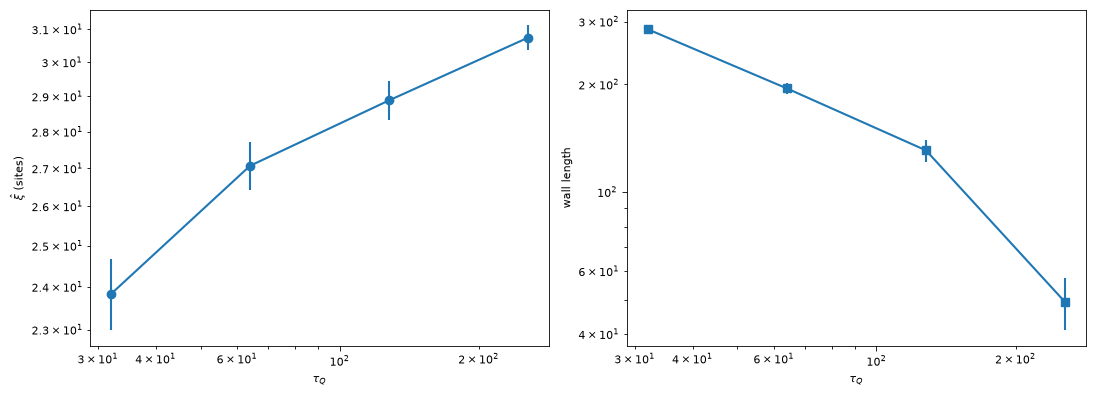

xi ~ tau^+0.120
wall ~ tau^-0.819


In [20]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt
import src.analysis as an

TAUS = [32, 64, 128, 256]
xi, wl, xi_e, wl_e = [], [], [], []

for tau in TAUS:
    d = an.load_chunk(tau)
    x = an.correlation_length(d["phi_final"])
    w = an.wall_length(d["phi_final"])
    xi.append(x.mean());  xi_e.append(x.std()/np.sqrt(len(x)))
    wl.append(w.mean());  wl_e.append(w.std()/np.sqrt(len(w)))
    print(f"tau={tau:4d}  xi={x.mean():5.1f}±{x.std():4.1f}   "
          f"wall={w.mean():5.0f}   box/xi={128/x.mean():.1f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].errorbar(TAUS, xi, yerr=xi_e, fmt="o-")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("$\\tau_Q$"); ax[0].set_ylabel("$\\hat\\xi$ (sites)")

ax[1].errorbar(TAUS, wl, yerr=wl_e, fmt="s-")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("$\\tau_Q$"); ax[1].set_ylabel("wall length")
plt.tight_layout(); plt.show()

# fitted exponents
for name, y in [("xi", xi), ("wall", wl)]:
    p = np.polyfit(np.log(TAUS), np.log(y), 1)
    print(f"{name} ~ tau^{p[0]:+.3f}")

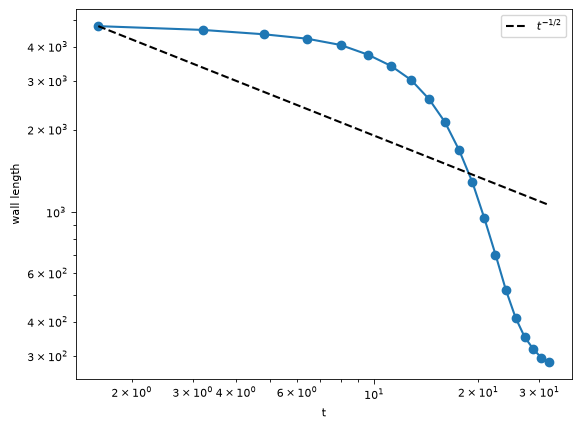

In [24]:
d = an.load_chunk(32)
wl_t = np.array([an.wall_length(d["snaps"][:, i]).mean()
                 for i in range(len(d["snap_times"]))])
t = d["snap_times"]
m = t > 0
plt.loglog(t[m], wl_t[m], "o-")
plt.loglog(t[m], wl_t[m][0]*(t[m]/t[m][0])**-0.5, "k--", label="$t^{-1/2}$")
plt.xlabel("t"); plt.ylabel("wall length"); plt.legend(); plt.show()

In [23]:
p = np.polyfit(np.log(TAUS[:3]), np.log(wl[:3]), 1)
print(f"wall ~ tau^{p[0]:+.3f}   (KZ: -nu/(1+z nu))")

wall ~ tau^-0.563   (KZ: -nu/(1+z nu))


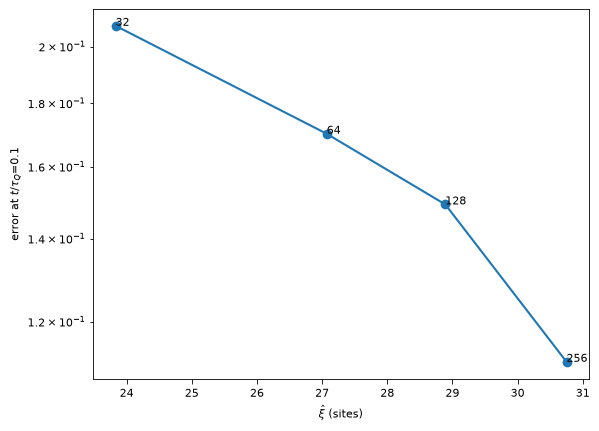

In [21]:
frac = 0.1                        # fixed t/tau
err  = []
for tau in TAUS:
    res = an.load_results(tau)
    m = [r for r in res if abs(r["t_used"]/tau - frac) < 1e-6]
    err.append(1 - m[0]["test_acc"] if m else np.nan)

err = np.array(err)
plt.plot(xi, err, "o-")
for t, x, e in zip(TAUS, xi, err):
    plt.annotate(f"{t}", (x, e), fontsize=8)
plt.xlabel("$\\hat\\xi$ (sites)"); plt.ylabel(f"error at $t/\\tau_Q$={frac}")
plt.yscale("log"); plt.show()

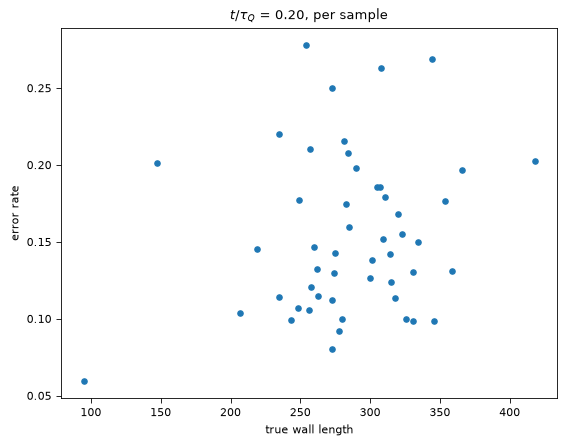

correlation: 0.196


In [22]:
d = an.load_chunk(32)
res = [r for r in an.load_results(32) if r["has_ckpt"]]
r = res[len(res)//2]
model, meta = an.load_model(r["tag"])
X, t_used = an.snapshot_at(d, meta["t_used"])
pred = an.predict(model, X, meta["scale"])
Y = d["phi_final"] > 0

acc_i = (pred == Y).mean(axis=(1, 2))
wl_i  = an.wall_length(d["phi_final"])

plt.scatter(wl_i, 1 - acc_i, s=14)
plt.xlabel("true wall length"); plt.ylabel("error rate")
plt.title(f"$t/\\tau_Q$ = {t_used/32:.2f}, per sample")
plt.show()
print("correlation:", np.corrcoef(wl_i, 1 - acc_i)[0, 1].round(3))